# Visualization

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


PLOT_FOLDER = "plots/"

df_base = pd.read_csv("results.csv")
df_base = df_base[df_base["Model Name"] == "vit_base"]
df_improved = pd.read_csv("improved_results.csv")
df_improved.head()

,Model Name,Dataset Size,Translation X,Translation Y,Rotation,Scale,Shear X,Shear Y,Top-1 Accuracy,Top-5 Accuracy,Type,Time
0,vit_base,5000,0,0,0.0,1.0,0,0,0.7140,0.9164,TTA_4,64.31
1,vit_base,5000,0,0,30.0,1.0,0,0,0.7050,0.9086,TTA_4,70.41
2,vit_base,5000,0,0,60.0,1.0,0,0,0.7024,0.9022,TTA_4,64.42
3,vit_base,5000,0,0,90.0,1.0,0,0,0.7330,0.9238,TTA_4,64.68
4,vit_base,5000,0,0,120.0,1.0,0,0,0.7106,0.9078,TTA_4,64.92


### TTA

In [26]:
# Polar plot: baseline vs rotations
def plot_tta_polar(df_base, df_improved, top, title="Title"):
    # locate baseline (no translation, no rotation, scale=1, no shear)
    baseline_row = df_base[
        (df_base["Translation X"] == 0)
        & (df_base["Translation Y"] == 0)
        & (df_base["Rotation"] == 0.0)
        & (df_base["Scale"] == 1.0)
        & (df_base["Shear X"] == 0)
        & (df_base["Shear Y"] == 0)
    ]
    if len(baseline_row) > 0:
        baseline = baseline_row[f"Top-{top} Accuracy"].iloc[0]

    # select rotation-only rows (no translation, scale=1, no shear)
    rot_df = df_base[
        (df_base["Translation X"] == 0)
        & (df_base["Translation Y"] == 0)
        & (df_base["Scale"] == 1.0)
        & (df_base["Shear X"] == 0)
        & (df_base["Shear Y"] == 0)
        & (df_base["Rotation"] != 0.0)
    ]
    rot_df = rot_df.sort_values("Rotation")
    angles = rot_df["Rotation"].values
    r_vals = rot_df[f"Top-{top} Accuracy"].values

    rot_tt4_df_improved = df_improved[
        (df_improved["Type"] == "TTA_4")
        & (df_improved["Translation X"] == 0)
        & (df_improved["Translation Y"] == 0)
        & (df_improved["Scale"] == 1.0)
        & (df_improved["Shear X"] == 0)
        & (df_improved["Shear Y"] == 0)
    ]
    rot_tt8_df_improved = df_improved[
        (df_improved["Type"] == "TTA_8")
        & (df_improved["Translation X"] == 0)
        & (df_improved["Translation Y"] == 0)
        & (df_improved["Scale"] == 1.0)
        & (df_improved["Shear X"] == 0)
        & (df_improved["Shear Y"] == 0)
    ]
    rot_tt12_df_improved = df_improved[
        (df_improved["Type"] == "TTA_12")
        & (df_improved["Translation X"] == 0)
        & (df_improved["Translation Y"] == 0)
        & (df_improved["Scale"] == 1.0)
        & (df_improved["Shear X"] == 0)
        & (df_improved["Shear Y"] == 0)
    ]
    rot_tt4_df_improved = rot_tt4_df_improved.sort_values("Rotation")
    rot_tt8_df_improved = rot_tt8_df_improved.sort_values("Rotation")
    rot_tt12_df_improved = rot_tt12_df_improved.sort_values("Rotation")
    r_vals_tt4_improved = rot_tt4_df_improved[f"Top-{top} Accuracy"].values
    r_vals_tt8_improved = rot_tt8_df_improved[f"Top-{top} Accuracy"].values
    r_vals_tt12_improved = rot_tt12_df_improved[f"Top-{top} Accuracy"].values

    # include baseline at 0 degrees in the plotted points
    angles_with_baseline = np.concatenate(([0.0], angles))
    r_with_baseline = np.concatenate(([baseline], r_vals))
    
    # sort by angle so the polar line is ordered correctly
    order = np.argsort(angles_with_baseline)
    angles_deg = angles_with_baseline[order]
    r = r_with_baseline[order]
    thetas = np.deg2rad(angles_deg)

    r_tt4_improved = r_vals_tt4_improved[order]
    r_tt8_improved = r_vals_tt8_improved[order]
    r_tt12_improved = r_vals_tt12_improved[order]

    # close the loop for a continuous polar line
    thetas_closed = np.concatenate([thetas, thetas[:1]])
    r_closed = np.concatenate([r, r[:1]])
    r_tt4_improved_closed = np.concatenate([r_tt4_improved, r_tt4_improved[:1]])
    r_tt8_improved_closed = np.concatenate([r_tt8_improved, r_tt8_improved[:1]])
    r_tt12_improved_closed = np.concatenate([r_tt12_improved, r_tt12_improved[:1]])

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, polar=True)
    ax.plot(thetas_closed, r_closed, marker="o", label=f"Top-{top} Accuracy", color="skyblue" if top == 1 else "C1")
    ax.plot(thetas_closed, r_tt4_improved_closed, marker="o", label=f"TTA-4 Top-{top} Accuracy", color="C2")
    ax.plot(thetas_closed, r_tt8_improved_closed, marker="s", label=f"TTA-8 Top-{top} Accuracy", color="C3")
    ax.plot(thetas_closed, r_tt12_improved_closed, marker="^", label=f"TTA-12 Top-{top} Accuracy", color="C4")
    # baseline as a dashed circle
    ax.plot(
        np.linspace(0, 2 * np.pi, 200),
        np.full(200, baseline),
        linestyle="--",
        color="skyblue" if top == 1 else "C1",
        label=f"Baseline Top-{top}",
    )
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    # label the grid at rotation angles
    if len(angles_deg) > 0:
        ax.set_thetagrids(angles_deg)
    ax.set_title(title, fontsize=20)
    ax.set_rlim(0, 1.0)

    # Set the axis fontsize to 16
    # ax.tick_params(axis='both', which='major', labelsize=16)

    # set the axis titlesize to 18
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)
    
    ax.legend()

    plt.savefig(f"{PLOT_FOLDER}vit_base_TTA_top-{top}.png", dpi=300, bbox_inches="tight")
    plt.show()

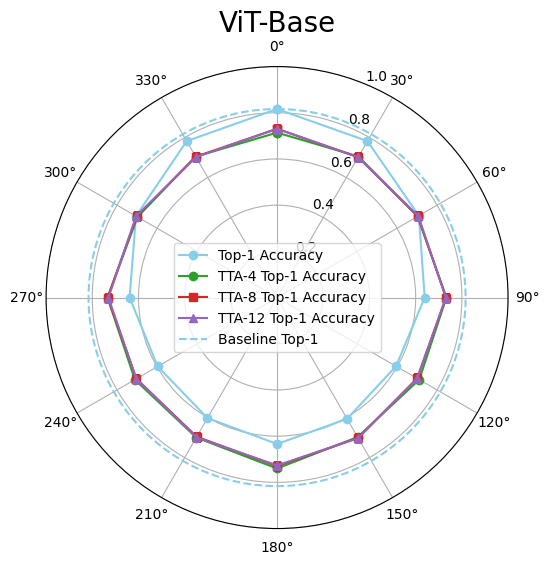

In [36]:
plot_tta_polar(df_base, df_improved, top=1, title="ViT-Base")

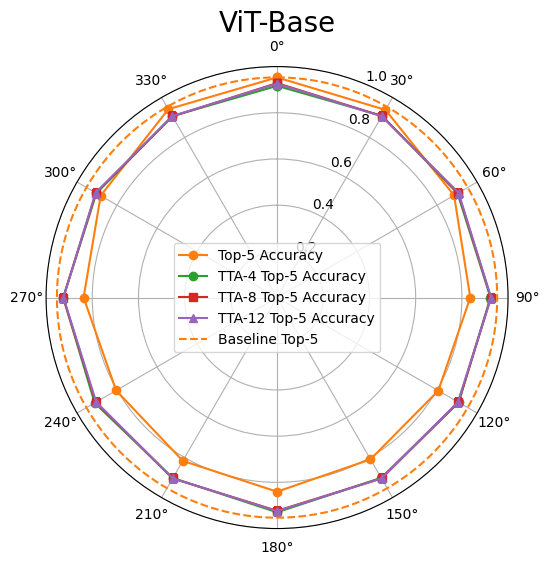

In [37]:
plot_tta_polar(df_base, df_improved, top=5, title="ViT-Base")

### Feature Averaging

In [32]:
# Polar plot: baseline vs rotations
def plot_fa_polar(df_base, df_improved, top, title="Title"):
    # locate baseline (no translation, no rotation, scale=1, no shear)
    baseline_row = df_base[
        (df_base["Translation X"] == 0)
        & (df_base["Translation Y"] == 0)
        & (df_base["Rotation"] == 0.0)
        & (df_base["Scale"] == 1.0)
        & (df_base["Shear X"] == 0)
        & (df_base["Shear Y"] == 0)
    ]
    if len(baseline_row) > 0:
        baseline = baseline_row[f"Top-{top} Accuracy"].iloc[0]

    # select rotation-only rows (no translation, scale=1, no shear)
    rot_df = df_base[
        (df_base["Translation X"] == 0)
        & (df_base["Translation Y"] == 0)
        & (df_base["Scale"] == 1.0)
        & (df_base["Shear X"] == 0)
        & (df_base["Shear Y"] == 0)
        & (df_base["Rotation"] != 0.0)
    ]
    rot_df = rot_df.sort_values("Rotation")
    angles = rot_df["Rotation"].values
    r_vals = rot_df[f"Top-{top} Accuracy"].values

    rot_tt4_df_improved = df_improved[
        (df_improved["Type"] == "feature_averaging_4")
        & (df_improved["Translation X"] == 0)
        & (df_improved["Translation Y"] == 0)
        & (df_improved["Scale"] == 1.0)
        & (df_improved["Shear X"] == 0)
        & (df_improved["Shear Y"] == 0)
    ]
    rot_tt8_df_improved = df_improved[
        (df_improved["Type"] == "feature_averaging_8")
        & (df_improved["Translation X"] == 0)
        & (df_improved["Translation Y"] == 0)
        & (df_improved["Scale"] == 1.0)
        & (df_improved["Shear X"] == 0)
        & (df_improved["Shear Y"] == 0)
    ]
    rot_tt12_df_improved = df_improved[
        (df_improved["Type"] == "feature_averaging_12")
        & (df_improved["Translation X"] == 0)
        & (df_improved["Translation Y"] == 0)
        & (df_improved["Scale"] == 1.0)
        & (df_improved["Shear X"] == 0)
        & (df_improved["Shear Y"] == 0)
    ]
    rot_tt4_df_improved = rot_tt4_df_improved.sort_values("Rotation")
    rot_tt8_df_improved = rot_tt8_df_improved.sort_values("Rotation")
    rot_tt12_df_improved = rot_tt12_df_improved.sort_values("Rotation")
    r_vals_tt4_improved = rot_tt4_df_improved[f"Top-{top} Accuracy"].values
    r_vals_tt8_improved = rot_tt8_df_improved[f"Top-{top} Accuracy"].values
    r_vals_tt12_improved = rot_tt12_df_improved[f"Top-{top} Accuracy"].values

    # include baseline at 0 degrees in the plotted points
    angles_with_baseline = np.concatenate(([0.0], angles))
    r_with_baseline = np.concatenate(([baseline], r_vals))
    
    # sort by angle so the polar line is ordered correctly
    order = np.argsort(angles_with_baseline)
    angles_deg = angles_with_baseline[order]
    r = r_with_baseline[order]
    thetas = np.deg2rad(angles_deg)

    r_tt4_improved = r_vals_tt4_improved[order]
    r_tt8_improved = r_vals_tt8_improved[order]
    r_tt12_improved = r_vals_tt12_improved[order]

    # close the loop for a continuous polar line
    thetas_closed = np.concatenate([thetas, thetas[:1]])
    r_closed = np.concatenate([r, r[:1]])
    r_tt4_improved_closed = np.concatenate([r_tt4_improved, r_tt4_improved[:1]])
    r_tt8_improved_closed = np.concatenate([r_tt8_improved, r_tt8_improved[:1]])
    r_tt12_improved_closed = np.concatenate([r_tt12_improved, r_tt12_improved[:1]])

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, polar=True)
    ax.plot(thetas_closed, r_closed, marker="o", label=f"Top-{top} Accuracy", color="skyblue" if top == 1 else "C1")
    ax.plot(thetas_closed, r_tt4_improved_closed, marker="o", label=f"FA-4 Top-{top} Accuracy", color="C2")
    ax.plot(thetas_closed, r_tt8_improved_closed, marker="s", label=f"FA-8 Top-{top} Accuracy", color="C3")
    ax.plot(thetas_closed, r_tt12_improved_closed, marker="^", label=f"FA-12 Top-{top} Accuracy", color="C4")
    # baseline as a dashed circle
    ax.plot(
        np.linspace(0, 2 * np.pi, 200),
        np.full(200, baseline),
        linestyle="--",
        color="skyblue" if top == 1 else "C1",
        label=f"Baseline Top-{top}",
    )
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    # label the grid at rotation angles
    if len(angles_deg) > 0:
        ax.set_thetagrids(angles_deg)
    ax.set_title(title, fontsize=20)
    ax.set_rlim(0, 1.0)

    # Set the axis fontsize to 16
    # ax.tick_params(axis='both', which='major', labelsize=16)

    # set the axis titlesize to 18
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)
    
    ax.legend()

    plt.savefig(f"{PLOT_FOLDER}vit_base_FA_top-{top}.png", dpi=300, bbox_inches="tight")
    plt.show()

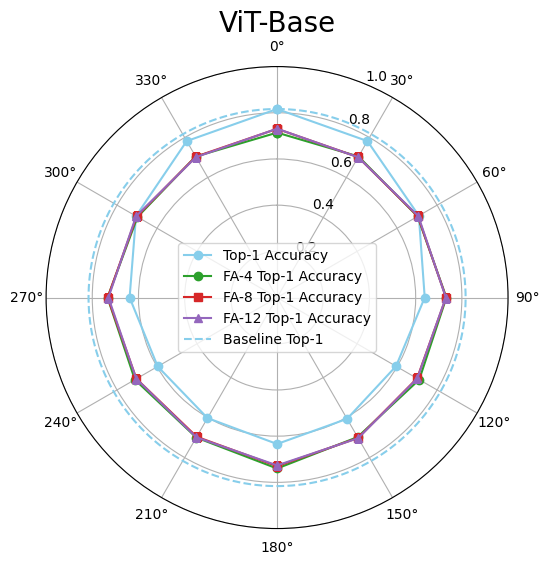

In [34]:
plot_fa_polar(df_base, df_improved, top=1, title="ViT-Base")

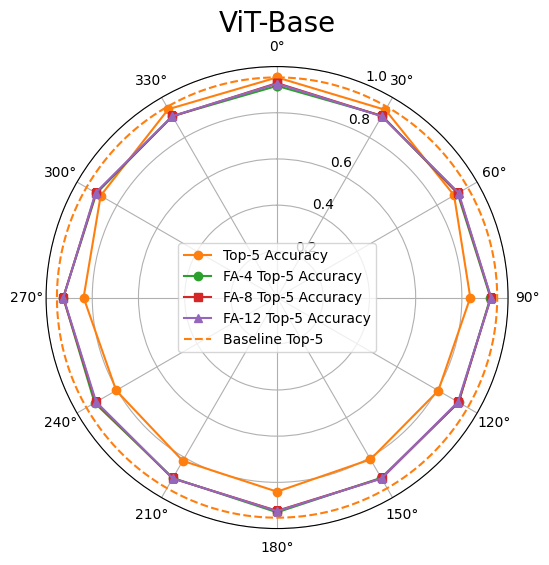

In [35]:
plot_fa_polar(df_base, df_improved, top=5, title="ViT-Base")

### Canonicalization

In [86]:
def plot_scatter_canonicalization(df_base, df_improved):
    # Include the baseline row
    baseline_row = df_base[
        (df_base["Translation X"] == 0)
        & (df_base["Translation Y"] == 0)
        & (df_base["Rotation"] == 0.0)
        & (df_base["Scale"] == 1.0)
        & (df_base["Shear X"] == 0)
        & (df_base["Shear Y"] == 0)
    ]

    base = df_base[
        (df_base["Translation X"] == 0)
        & (df_base["Translation Y"] == 0)
        & (df_base["Rotation"] != 0.0)
        & (df_base["Scale"] == 1.0)
        & (df_base["Shear X"] == 0)
        & (df_base["Shear Y"] == 0)
    ]
    base = pd.concat([base, baseline_row], ignore_index=True)
    base_top_1 = base["Top-1 Accuracy"].values.mean()
    base_top_5 = base["Top-5 Accuracy"].values.mean()
    base_time = base["Time"].values.mean()

    df_canonical = df_improved[
        (df_improved["Type"].str.contains("canonicalizer"))
    ]

    # Compute top-1, top-5, and time for each canonicalizer type
    results = []
    for canonicalizer_type in df_canonical["Type"].unique():
        canonical_data = df_canonical[df_canonical["Type"] == canonicalizer_type]
        top_1 = canonical_data["Top-1 Accuracy"].values.mean()
        top_5 = canonical_data["Top-5 Accuracy"].values.mean()
        time = canonical_data["Time"].values.mean()
        results.append((canonicalizer_type, top_1, top_5, time))
    # sort results by name
    results.sort(key=lambda x: x[0])
    
    # Create scatter plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for canonicalizer_type, top_1, top_5, time in results:
        axes[0].scatter(time, top_1, label="_".join(canonicalizer_type.split("_")[1:]))
        axes[1].scatter(time, top_5, label="_".join(canonicalizer_type.split("_")[1:]))

    # Add baseline points
    axes[0].scatter(base_time, base_top_1, label="No Canonicalization", color="black", marker="x", s=100)
    axes[1].scatter(base_time, base_top_5, label="No Canonicalization", color="black", marker="x", s=100)

    axes[0].set_xlabel("Execution Time (s)")
    axes[0].set_ylabel("Top-1 Accuracy")
    axes[0].grid()
    axes[1].set_xlabel("Execution Time (s)")
    axes[1].set_ylabel("Top-5 Accuracy")
    axes[1].grid()

    # Place title in the center above both subplots
    fig.suptitle("ViT Base", fontsize=20)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"{PLOT_FOLDER}canonicalization_scatter.png", dpi=300, bbox_inches="tight")
    plt.show()

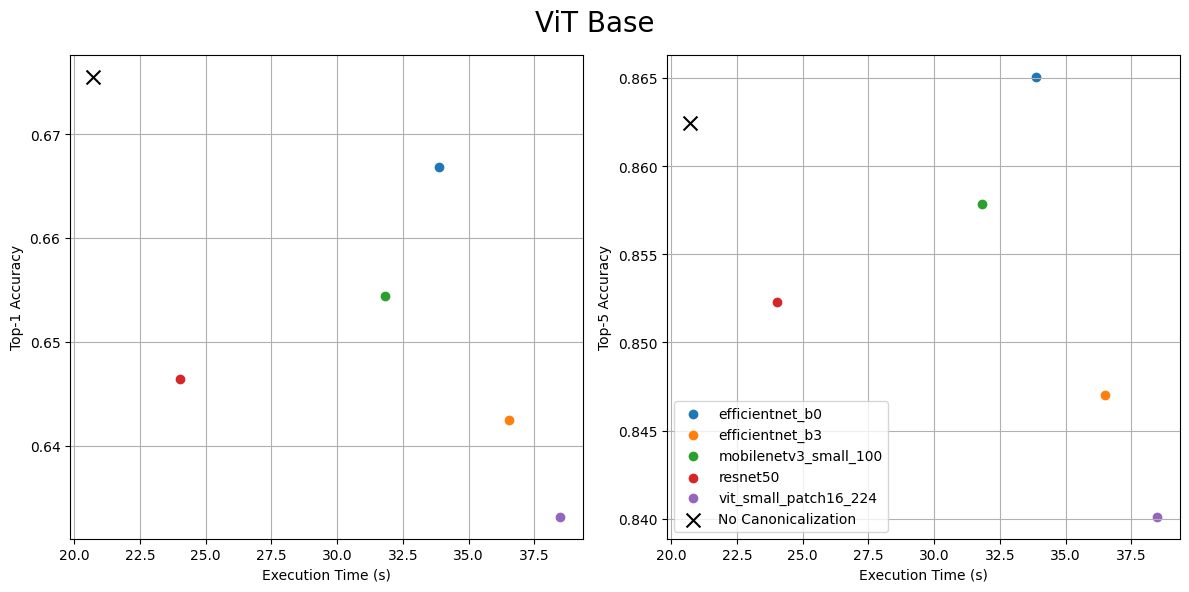

In [87]:
plot_scatter_canonicalization(df_base, df_improved)

### Execution Times

In [43]:
def plot_execution_times(df_base, df_improved):
    # Filter for the baseline and improved methods
    base_time = df_base[
        (df_base["Translation X"] == 0)
        & (df_base["Translation Y"] == 0)
        & (df_base["Rotation"] != 0.0)
        & (df_base["Scale"] == 1.0)
        & (df_base["Shear X"] == 0)
        & (df_base["Shear Y"] == 0)
    ]["Time"].mean()

    tta4_time = df_improved[df_improved["Type"] == "TTA_4"]["Time"].mean()
    tta8_time = df_improved[df_improved["Type"] == "TTA_8"]["Time"].mean()
    tta12_time = df_improved[df_improved["Type"] == "TTA_12"]["Time"].mean()

    fa4_time = df_improved[df_improved["Type"] == "feature_averaging_4"]["Time"].mean()
    fa8_time = df_improved[df_improved["Type"] == "feature_averaging_8"]["Time"].mean()
    fa12_time = df_improved[df_improved["Type"] == "feature_averaging_12"]["Time"].mean()

    methods = ["No Augmentations", "TTA-4", "TTA-8", "TTA-12", "FA-4", "FA-8", "FA-12"]
    times = [base_time, tta4_time, tta8_time, tta12_time, fa4_time, fa8_time, fa12_time]

    plt.figure(figsize=(12, 6))
    plt.bar(methods, times, color=["C1", "C2", "C3", "C4", "C2", "C3", "C4"])
    plt.ylabel("Average Execution Time (s)", fontsize=16)
    plt.title("Average Execution Times", fontsize=20)
    plt.xticks(rotation=45, fontsize=14)
    plt.yticks(fontsize=14)
    
    for i, time in enumerate(times):
        plt.text(i, time + max(times)*0.01, f"{time:.2f}s", ha="center", fontsize=12)

    plt.tight_layout()
    plt.savefig(f"{PLOT_FOLDER}execution_times.png", dpi=300, bbox_inches="tight")
    plt.show()

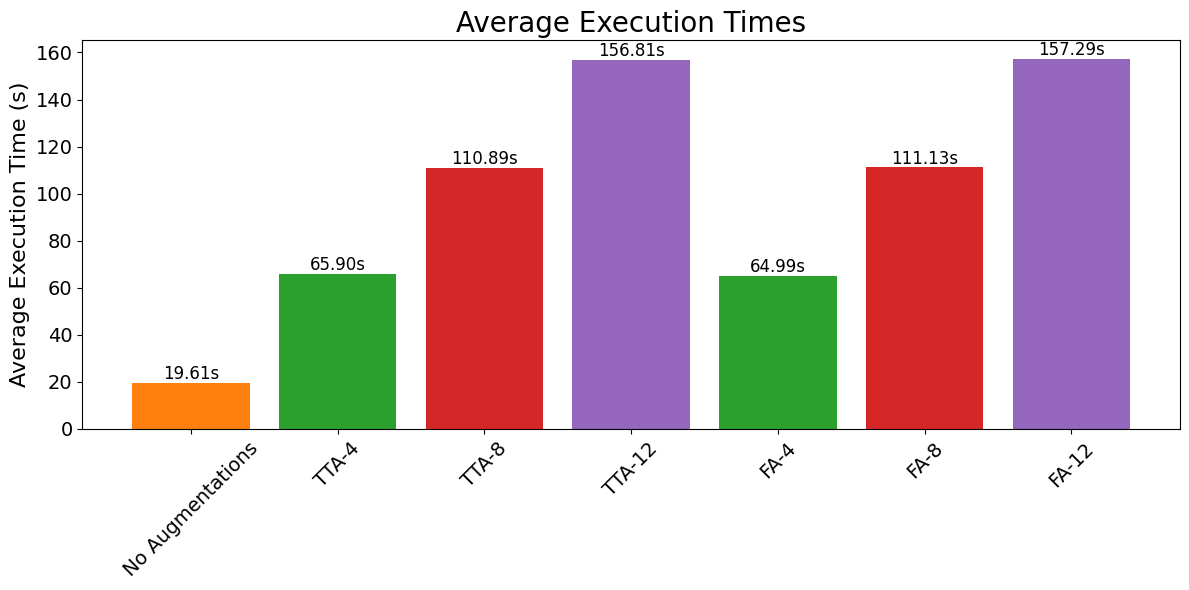

In [44]:
plot_execution_times(df_base, df_improved)